In [1]:
# -*- coding: utf-8 -*-
#  Copyright 2025 United Kingdom Research and Innovation
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#  Authored by:    Laura Murgatroyd (UKRI-STFC)

In [2]:
from cil.io import NEXUSDataReader
from cil.utilities.display import show2D
import os
from matplotlib import pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

from cil.utilities.display import show2D
from cil.processors import Slicer

from data_io.io import read_mantid_imaging_data
from recon.weighted_fbp import run_weighted_fbp_parallel
from utils.lego_man import calculate_metrics, make_bar_plots
from cil.utilities.display import show1D

In [3]:
sirt_result = NEXUSDataReader('outputs/golden_angle_lego/sirt_25_percent.nxs').read()
sirt_nn_result = NEXUSDataReader('outputs/golden_angle_lego/sirt_nn_25_percent.nxs').read()
pdhg_result = NEXUSDataReader('outputs/golden_angle_lego/pdhg_25_percent.nxs').read()
fista_result = NEXUSDataReader('outputs/golden_angle_lego/fista_25_percent.nxs').read()


In [4]:
base_path = "/home/lhe97136/Data/Lego GR Investigation/Data for Release/preprocessed_data/"
gr_full = read_mantid_imaging_data(os.path.join(base_path, "Golden_Ratio"), pixel_size=100*10**-4)
equi_full = read_mantid_imaging_data(os.path.join(base_path, "Equidistant"), pixel_size=100*10**-4)

In [5]:
gr_scale = 0.25
gr_slice = Slicer(roi={'angle': (0, 457 * gr_scale), 'vertical': (317, 318)})(gr_full)
gr_slice_fbp = run_weighted_fbp_parallel(gr_slice) 

In [6]:
equi_full_slice = equi_full.get_slice(vertical=317)
equi_full_slice.reorder('astra')
equi_full_recon = run_weighted_fbp_parallel(equi_full_slice)

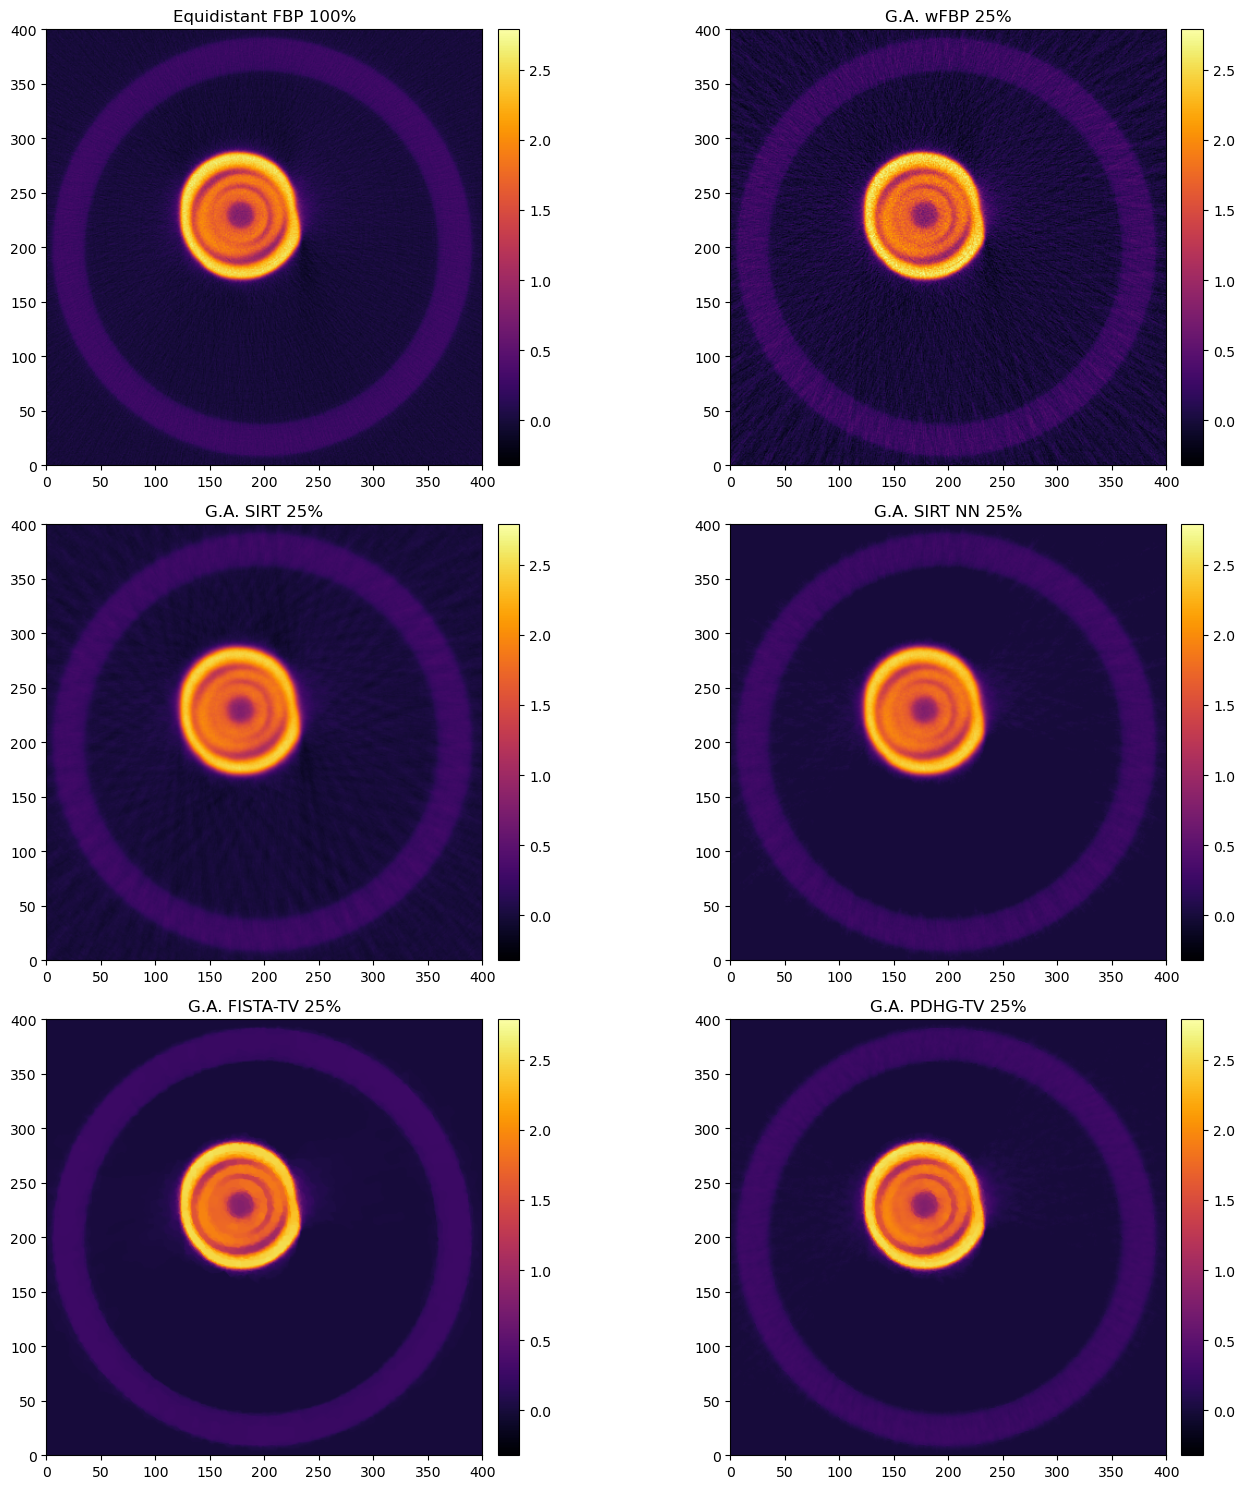

In [7]:
data_list = [equi_full_recon, gr_slice_fbp, sirt_result, sirt_nn_result, fista_result, pdhg_result]
titles = ['Equidistant FBP 100%', 'G.A. wFBP 25%', 'G.A. SIRT 25%', 'G.A. SIRT NN 25%', 'G.A. FISTA-TV 25%', 'G.A. PDHG-TV 25%']
# min should be min of all data:
m = min([data.array.min() for data in data_list])
mx = max([data.array.max() for data in data_list])
show2D([data.array[75:475, 100:500] for data in data_list], title=titles, fix_range=(m, mx), cmap='inferno')

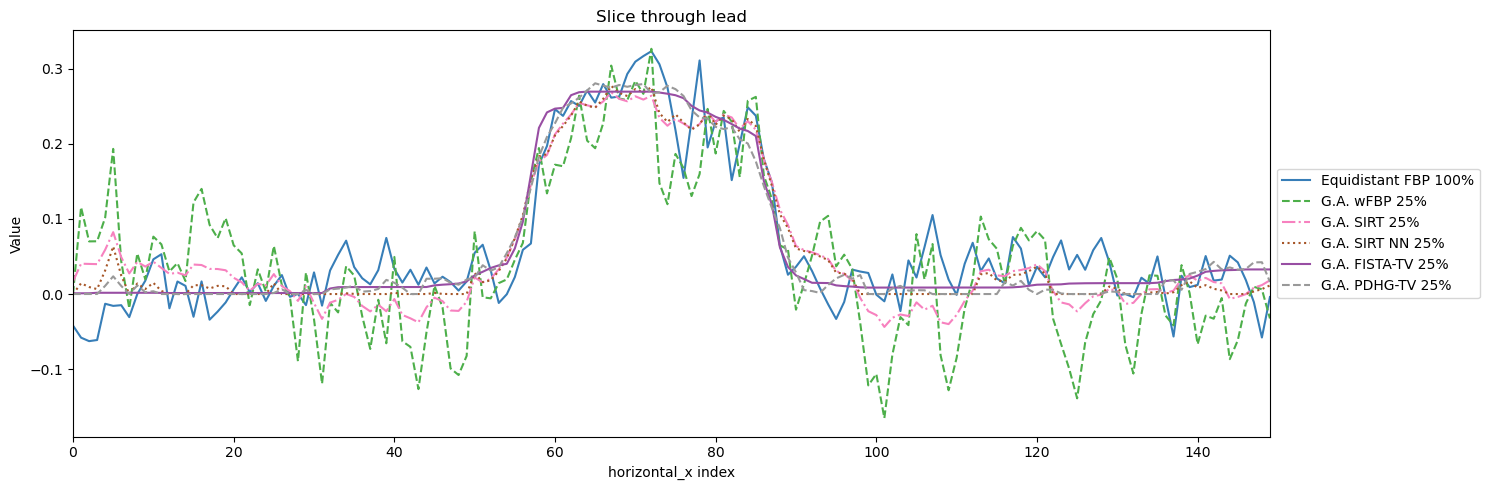

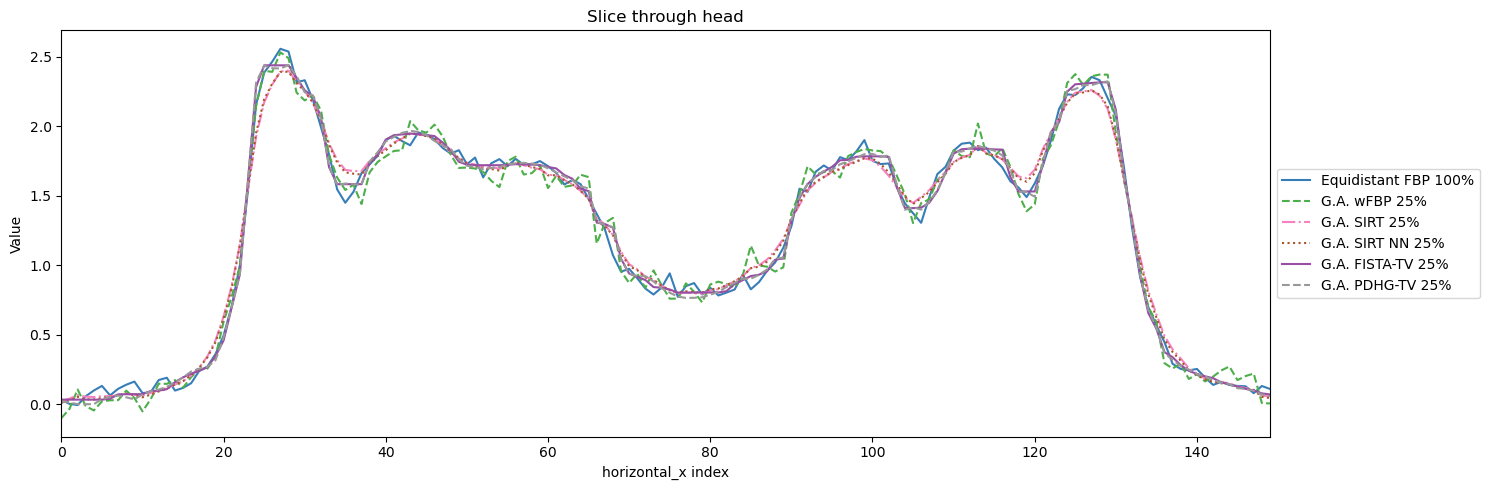

In [8]:
show1d_slicer_lead = Slicer(roi={'horizontal_x':(50,200)})
show1d_slicer_head = Slicer(roi={'horizontal_x':(200,350)})

colors = ['#377eb8', '#4daf4a',
                    '#f781bf', '#a65628', '#984ea3',
                    '#999999', '#e41a1c', '#dede00']
show1D([show1d_slicer_lead(x) for x in data_list], slice_list=[('horizontal_y', 300)], dataset_labels=titles, title="Slice through lead", size=(15,5), line_colours=colors)
show1D([show1d_slicer_head(x) for x in data_list], slice_list=[('horizontal_y', 300)], dataset_labels=titles, title="Slice through head", size=(15,5), line_colours=colors)


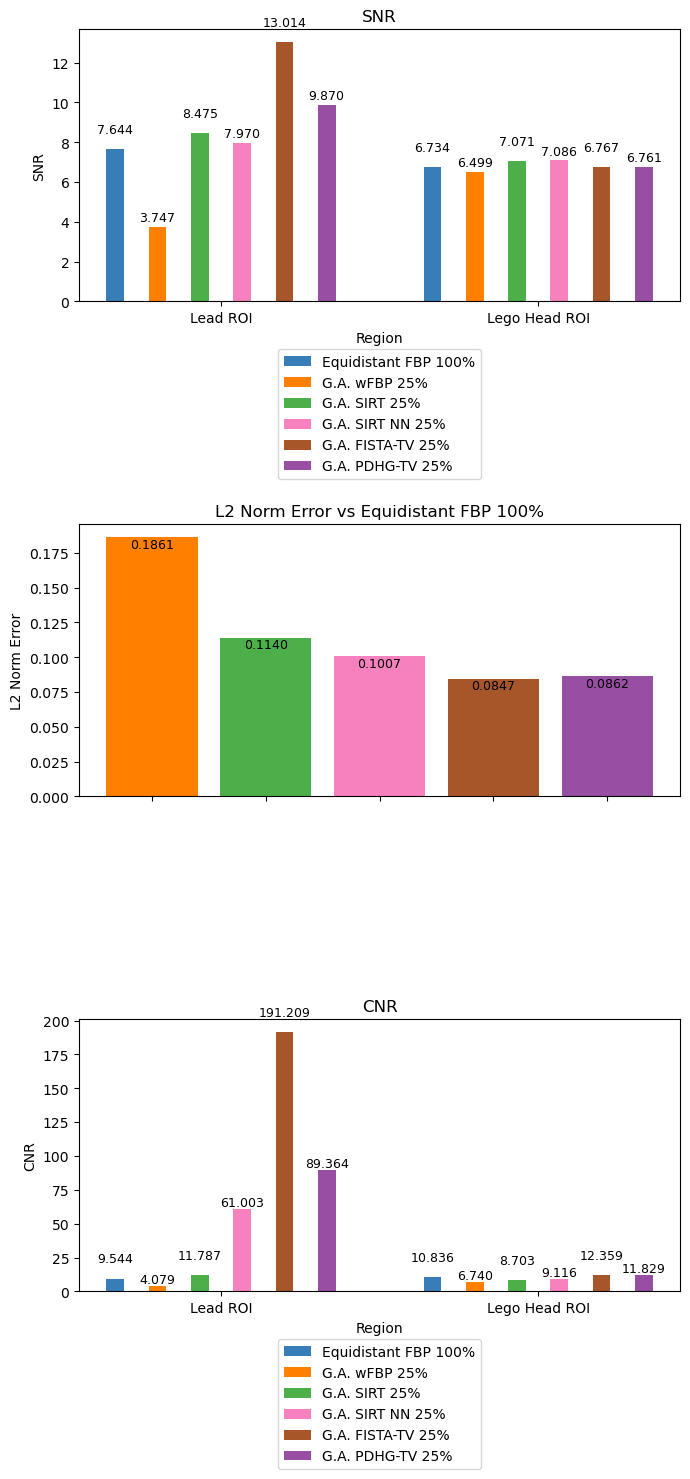

In [9]:
l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner  = calculate_metrics(data_list[0], data_list[1:])
make_bar_plots(l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner, titles, orientation='vertical')

FISTA-TV performs the best overall when taking into account the metrics and line profiles.
It could be that FISTA has performed better than PDHG because it reached convergence unlike PDHG (see Golden_Angle_04_PDHG_TV.ipynb and Golden_Angle_05_FISTA.ipynb), or maybe our choice of alpha parameter was better.

It even performs better than the FBP of the full scan across the metrics! But note - the metrics we've used have limitations: In future it would be great to add more metrics which study the sharpness and sizes of features in the images, and that encapsulate the contrast and sharpness between air and lego between each layer of the head. We could even try with fewer projections as well!

We have demonstrated the feasibility of using iterative methods to retrieve quality from even 25% of data when the golden ratio acquisition protocol is used.